In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import pandas as pd


### Positional Encoding

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

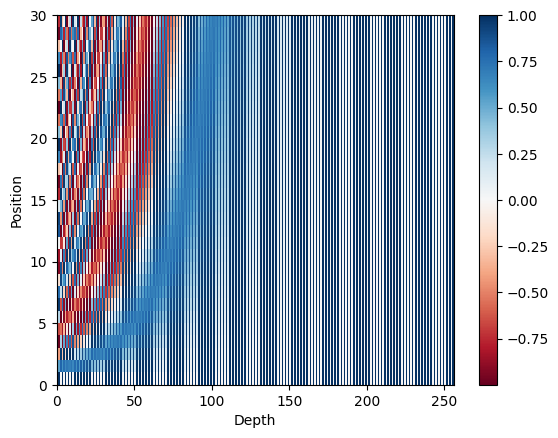

In [3]:
sample_pos_encoding = PositionalEncoding(30, 256)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 256))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### Scaled Dot Product Attention

In [4]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

### Multihead Attention

내부적으로는 Scaled Dot Product Attention 함수를 호출

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


## Masking
### Padding Masking  
정해준 길이보다 짧은 문장의 경우에는 숫자 0을 채워서 문장의 길이를 맞춰줌

In [6]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [7]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


### Look-ahead Masking
다음 단어 가리기

In [8]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [9]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [10]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


## Encoder
### Encoder Layer

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


### Encoder Layer 을 쌓아 Encoder 생성

In [12]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

## Decoder
### Decoder Layer

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

### Decoder Layer 을 쌓아 Decoder 생성

In [14]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

## 병렬 데이터 구조 생성
### 데이터 로드

In [15]:
# 1. 데이터 로드
file_path = 'chatbot_data/ChatbotData.csv'
train_data = pd.read_csv(file_path)

# 2. 질문과 답변 리스트 생성
questions = train_data['Q'].tolist()
answers = train_data['A'].tolist()

print(f"전체 데이터 개수: {len(questions)}")
print("Q:", questions[0])
print("A:", answers[0])

전체 데이터 개수: 11823
Q: 12시 땡!
A: 하루가 또 가네요.


In [16]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = len(questions) # 전체 사용
print(MAX_SAMPLES)

11823


### 한국어 전처리 함수

In [17]:
# 한국어 전처리 함수
def preprocess_sentence(sentence):
    # 양쪽 공백 제거
    sentence = sentence.strip()
    
    # 단어와 구두점(.,!?) 사이의 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글, 알파벳, 숫자, 구두점을 제외한 모든 문자를 공백으로 대체합니다.
    sentence = re.sub(r"[^a-zA-Z0-9가-힣?.!,]+", " ", sentence)
    
    return sentence.strip()

In [18]:
# 전처리 테스트

sample_sentence = "안녕하세요? Hello! I'm a student😊, sns ㅋㅋㅋㅋ! 1q2w3e4r!"
print(preprocess_sentence(sample_sentence)) 

안녕하세요 ? Hello ! I m a student , sns ! 1q2w3e4r !


## 병렬 데이터 전처리
### 데이터 정제 및 코퍼스 생성

In [19]:
# 11,823개 전체 데이터 전처리
processed_questions = [preprocess_sentence(q) for q in questions]
processed_answers = [preprocess_sentence(a) for a in answers]

# SentencePiece 학습을 위한 통합 코퍼스 생성
with open('chatbot_corpus.txt', 'w', encoding='utf-8') as f:
    for q, a in zip(processed_questions, processed_answers):
        f.write(q + '\n')
        f.write(a + '\n')

print("코퍼스 생성 완료! SNS, SD카드 등 알파벳이 포함되었습니다.")

코퍼스 생성 완료! SNS, SD카드 등 알파벳이 포함되었습니다.


### SentencePiece 토크나이저 학습

In [20]:
corpus_file = 'chatbot_corpus.txt' 
model_prefix = 'spm_chatbot_kor'

spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix=model_prefix,
    vocab_size=8000,
    character_coverage=1.0, # 한글은 모든 글자를 커버하는 1.0이 안전합니다
    model_type="bpe",
    max_sentence_length=2000, # 챗봇 문장은 짧으므로 2000정도면 넉넉합니다
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

print(f"한국어 토크나이저 학습 완료: {model_prefix}.model")


한국어 토크나이저 학습 완료: spm_chatbot_kor.model


In [21]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot_kor.model")

True

In [22]:
# Test Code

test_sentences = [
    "SNS 보면 나만 빼고 다 행복해 보여.",
    "3박 4일 정도 놀러가고 싶다!",
    "SD카드 망가졌어... PPL 너무 심하네."
]

for s in test_sentences:
    sentence = preprocess_sentence(s)
    print(f"\n[입력]: {s}")
    print(f"전처리 후: {sentence}")
    
    # 1. 토크나이징 (subword 단위로 분할)
    tokens = sp.encode(sentence, out_type=str)
    # 2. 인코딩 (서브워드를 정수 ID로 변환)
    encoded = sp.encode(sentence, out_type=int)
    # 3. 디코딩 (정수 ID → 원본 문장 복원)
    decoded = sp.decode(encoded)
    
    print(f"Tokenized: {tokens}")
    print(f"Encoded  : {encoded}")
    print(f"Decoded  : {decoded}")
    print("-" * 50)



[입력]: SNS 보면 나만 빼고 다 행복해 보여.
전처리 후: SNS 보면 나만 빼고 다 행복해 보여 .
Tokenized: ['▁SNS', '▁보면', '▁나만', '▁빼고', '▁다', '▁행복해', '▁보여', '▁.']
Encoded  : [1922, 1239, 471, 4160, 26, 1154, 1034, 4]
Decoded  : SNS 보면 나만 빼고 다 행복해 보여 .
--------------------------------------------------

[입력]: 3박 4일 정도 놀러가고 싶다!
전처리 후: 3박 4일 정도 놀러가고 싶다 !
Tokenized: ['▁3', '박', '▁4', '일', '▁정도', '▁놀러가고', '▁싶다', '▁!']
Encoded  : [475, 7278, 942, 6820, 983, 3493, 201, 108]
Decoded  : 3박 4일 정도 놀러가고 싶다 !
--------------------------------------------------

[입력]: SD카드 망가졌어... PPL 너무 심하네.
전처리 후: SD카드 망가졌어 . . . PPL 너무 심하네 .
Tokenized: ['▁S', 'D', '카드', '▁망가', '졌어', '▁.', '▁.', '▁.', '▁', 'P', 'P', 'L', '▁너무', '▁심', '하네', '▁.']
Encoded  : [1700, 7754, 4073, 4140, 655, 4, 4, 4, 6770, 7756, 7756, 7866, 56, 315, 483, 4]
Decoded  : SD카드 망가졌어 . . . PPL 너무 심하네 .
--------------------------------------------------


### Dataset 구현

In [23]:
class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp_processor):
        self.questions = questions  # 전처리된 질문 리스트
        self.answers = answers      # 전처리된 답변 리스트
        self.sp = sp_processor      # 학습시킨 SentencePiece 모델

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        # 1. 문장의 시작(BOS)과 끝(EOS)을 붙여 정수로 변환        
        q_ids = [self.sp.bos_id()] + self.sp.encode_as_ids(self.questions[idx]) + [self.sp.eos_id()]
        a_ids = [self.sp.bos_id()] + self.sp.encode_as_ids(self.answers[idx]) + [self.sp.eos_id()]
        
        return {
            'enc_input': torch.tensor(q_ids),
            'dec_input': torch.tensor(a_ids[:-1]), # 마지막 EOS 제외 (Teacher Forcing)
            'target': torch.tensor(a_ids[1:])      # 첫 번째 BOS 제외
        }

# 동적 패딩 처리 (Batch Size 에 맞춰 가변)
def collate_fn(batch):
    enc_inputs = pad_sequence([item['enc_input'] for item in batch], batch_first=True, padding_value=0)
    dec_inputs = pad_sequence([item['dec_input'] for item in batch], batch_first=True, padding_value=0)
    targets = pad_sequence([item['target'] for item in batch], batch_first=True, padding_value=0)
    return enc_inputs, dec_inputs, targets

In [24]:
# 인스턴스 생성
dataset = ChatbotDataset(processed_questions, processed_answers, sp)

### DataLoader 구성

In [25]:
# DataLoader 연결 (Batch Size 64)
dataloader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True,  # 데이터를 가져올 때 순서를 무작위로
    collate_fn=collate_fn  # 동적패딩
)

In [26]:
# Test Code

for enc_input, dec_input, dec_label in dataloader:
    print("--- 배치 텐서 정보 ---")
    print("인코더 입력 크기 :", enc_input.size()) # [64, 현재 배치 최장 길이]
    print("디코더 입력 크기 :", dec_input.size())
    print("디코더 라벨 크기 :", dec_label.size())
    
    print("\n--- 실제 데이터 샘플 (첫 번째 문장) ---")
    # 인코더 입력 (질문)
    print("Encoder Input (Raw IDs):\n", enc_input[0])
    print("Decoded Q:", sp.decode(enc_input[0].tolist()))
    
    # 디코더 입력 (Teacher Forcing용)
    print("\nDecoder Input (Raw IDs):\n", dec_input[0])
    print("Decoded Dec_In:", sp.decode(dec_input[0].tolist()))
    
    # 디코더 라벨 (정답)
    print("\nDecoder Label (Raw IDs):\n", dec_label[0])
    print("Decoded Label:", sp.decode(dec_label[0].tolist()))
    
    break # 한 배치만 확인하고 종료

--- 배치 텐서 정보 ---
인코더 입력 크기 : torch.Size([64, 14])
디코더 입력 크기 : torch.Size([64, 18])
디코더 라벨 크기 : torch.Size([64, 18])

--- 실제 데이터 샘플 (첫 번째 문장) ---
Encoder Input (Raw IDs):
 tensor([   1,   56, 3821, 1643,  846,    2,    0,    0,    0,    0,    0,    0,
           0,    0])
Decoded Q: 너무 불공평한거 같애

Decoder Input (Raw IDs):
 tensor([   1, 5596, 3914,  154,    4,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])
Decoded Dec_In: 남과 비교하지 마세요 .

Decoder Label (Raw IDs):
 tensor([5596, 3914,  154,    4,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])
Decoded Label: 남과 비교하지 마세요 .


## 모델 정의 및 학습
### Transformer 함수 정의

In [27]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

### 모델 생성

In [28]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

### 손실함수

In [29]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

### 커스텀 된 학습률
  
$$LearningRate = d_{model}^{-0.5} \cdot \min(\text{step}^{-0.5}, \text{step} \cdot \text{warmup\_steps}^{-1.5})$$

In [53]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1

        # [수식 해설]
        # 1. (d_model ** -0.5): 모델의 크기에 반비례하게 전체적인 학습률 규모를 조절합니다.
        # 2. step ** -0.5: 학습이 진행될수록 학습률을 서서히 낮춥니다. (Decay)
        # 3. step * (warmup_steps ** -1.5): 초기 warmup 기간 동안 학습률을 선형적으로 높입니다. (Warmup)
        
        # min() 함수를 통해 Warmup 단계와 Decay 단계 중 더 작은 값을 선택하여 
        # 산 모양(삼각형)의 학습률 곡선을 완성합니다.

        return 40 * (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

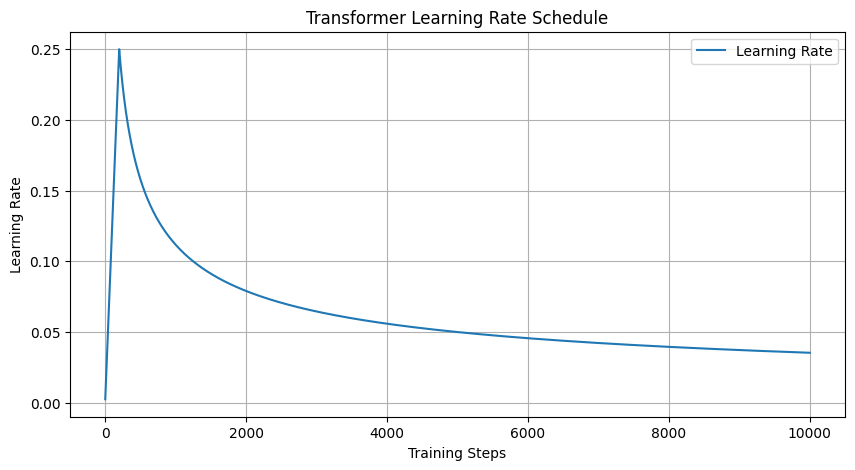

In [54]:
# 하이퍼파라미터 설정
D_MODEL = 128
WARMUP_STEPS = 200
TOTAL_STEPS = 10000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, TOTAL_STEPS + 1)
learning_rates = [get_lr_lambda(D_MODEL, WARMUP_STEPS)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


### 모델 컴파일

In [55]:
# Optimizer 정의: 모델의 가중치를 업데이트하는 알고리즘
optimizer = optim.Adam(model.parameters(), 
                       betas=(0.9, 0.98),  # 기울기의 이동평균 계수. 0.98을 사용하여 안정적인 학습 유도
                       eps=1e-9)           # 0으로 나누어지는 것을 방지하는 아주 작은 값

# Scheduler 정의 : 학습이 진행됨에 따라 Learning Rate를 동적으로 조절
# 앞서 정의한 get_lr_lambda 함수를 사용하여 Warmup 기간 동안은 상승, 이후엔 하강하는 곡선을 그립니다.
scheduler = lr_scheduler.LambdaLR(optimizer, 
                                  lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS))

# Accuracy Function: 모델의 예측 성능을 측정하는 지표
def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size) -> 각 단어별 확률 분포
    y_true: (batch_size, seq_len) -> 단어 인덱스 번호
    """
    
    # 모델의 출력 중 가장 확률이 높은 단어의 인덱스(ID)를 선택
    # dim=-1은 마지막 차원(vocab_size)에서 최댓값을 찾으라는 의미입니다.
    preds = y_pred.argmax(dim=-1) # 결과 크기: (batch_size, seq_len)

    # [중요] 마스킹 처리: 정답지(y_true)에서 패딩(0)이 아닌 부분만 True로 표시
    # 가변 패딩으로 채워진 0은 학습 대상이 아니므로 채점에서도 제외해야 합니다.
    mask = (y_true != pad_id)

    # 예측값과 실제값이 일치하는지 확인하고, 마스크를 씌워 '진짜 단어'인 것만 골라냄
    # & 연산자를 통해 (정답 여부)와 (패딩 아님 여부)를 동시에 만족해야 True
    correct = (preds == y_true) & mask

    # 최종 정확도 계산: (맞춘 진짜 단어 수) / (전체 진짜 단어 수)
    # float()으로 형변환하여 나눗셈 연산을 수행합니다.
    acc = correct.float().sum() / mask.float().sum()
    
    return acc

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 모델 훈련

In [57]:
def train_step(model, batch, optimizer, loss_function, device):
    # 1. 모델을 학습 모드로 설정 (Dropout 등이 활성화됨)
    model.train()

    # 2. 배치를 GPU(device)로 전송
    # enc_input: 질문, dec_input: 답변(입력), target: 답변(정답)
    enc_input, dec_input, target = [x.to(device) for x in batch]

    # 3. 지난 그래디언트(기울기)를 초기화
    optimizer.zero_grad()

    # 4. 모델 포워드 패스 (예측 수행)
    # logits shape: (batch_size, seq_len, vocab_size)
    logits = model(enc_input, dec_input)

    # 5. Loss 계산
    # CrossEntropyLoss는 (N, C, L) 형태를 원하므로 permute를 통해 
    # 클래스 차원(vocab_size)을 두 번째로 옮겨줍니다.
    # logits: (batch_size, vocab_size, seq_len) / target: (batch_size, seq_len)
    loss = loss_function(logits.permute(0, 2, 1), target)

    # 6. 역전파 (Backpropagation): 오차를 뒤로 전달하며 기울기 계산
    loss.backward()

    # 7. 가중치 업데이트: 계산된 기울기를 바탕으로 모델 파라미터 수정
    optimizer.step()

    # 손실값(loss)과 정확도(accuracy)를 반환 (시각화 및 모니터링용)
    # accuracy_function은 만들어진 마스크 기반 함수를 사용합니다.
    acc = accuracy_function(logits, target, pad_id=sp.pad_id())

    return loss.item(), acc

In [58]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def train(model, dataloader, val_dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    
    print(f"{'Epoch':^7} | {'T-Loss':^8} | {'T-Acc':^7} | {'V-Loss':^8} | {'V-Acc':^7} | {'LR':^9}")
    print("-" * 65)

    for epoch in range(num_epochs):
        # --- [TRAIN PHASE] ---
        model.train()
        total_loss, total_acc = 0, 0
        
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc
            
            scheduler.step() # 매 스텝마다 학습률 업데이트

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

        avg_train_loss = total_loss / len(dataloader)
        avg_train_acc = total_acc / len(dataloader)

        # --- [VALIDATION PHASE] ---
        # 매 에폭이 끝날 때마다 테스트(검증) 데이터로 성능 측정
        model.eval()
        val_loss, val_acc = 0, 0
        
        with torch.no_grad(): # 평가 시에는 기울기 계산 제외 (메모리 절약)
            for batch in val_dataloader:
                enc_input, dec_input, target = [x.to(device) for x in batch]
                
                logits = model(enc_input, dec_input)
                # Loss 계산 (학습 때와 동일하게 permute 적용)
                loss = loss_function(logits.permute(0, 2, 1), target)
                
                acc = accuracy_function(logits, target, pad_id=sp.pad_id())
                val_loss += loss.item()
                val_acc += acc

        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_acc = val_acc / len(val_dataloader)
        current_lr = optimizer.param_groups[0]['lr']

        # 기록 저장
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        # 결과 출력: 에폭당 딱 한 줄!
        print(f"{epoch+1:^7} | {avg_train_loss:^8.4f} | {avg_train_acc:^7.4f} | {avg_val_loss:^8.4f} | {avg_val_acc:^7.4f} | {current_lr:^9.7f}")

    return history

In [59]:
%%time

# 실행 및 기록 저장
history = train(
    model=model,
    dataloader=dataloader,
    val_dataloader=dataloader, # 분리된 검증셋
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=100,
    device=device
)


 Epoch  |  T-Loss  |  T-Acc  |  V-Loss  |  V-Acc  |    LR    
-----------------------------------------------------------------
[Epoch 1, Step 0] Loss: 3.3724, Acc: 0.4651
[Epoch 1, Step 100] Loss: 3.6695, Acc: 0.4305
   1    |  3.6109  | 0.4324  |  3.2779  | 0.4763  | 0.0002325
[Epoch 2, Step 0] Loss: 3.3493, Acc: 0.4808
[Epoch 2, Step 100] Loss: 3.5815, Acc: 0.4145
   2    |  3.5025  | 0.4399  |  3.0237  | 0.4949  | 0.0001836
[Epoch 3, Step 0] Loss: 3.5923, Acc: 0.4245
[Epoch 3, Step 100] Loss: 3.3737, Acc: 0.4147
   3    |  3.2826  | 0.4643  |  2.8244  | 0.5214  | 0.0001499
[Epoch 4, Step 0] Loss: 3.1356, Acc: 0.4833
[Epoch 4, Step 100] Loss: 3.1416, Acc: 0.5069
   4    |  3.1057  | 0.4842  |  2.6587  | 0.5383  | 0.0001299
[Epoch 5, Step 0] Loss: 2.9366, Acc: 0.4956
[Epoch 5, Step 100] Loss: 2.9990, Acc: 0.4886
   5    |  2.9632  | 0.5020  |  2.5137  | 0.5611  | 0.0001162
[Epoch 6, Step 0] Loss: 2.6760, Acc: 0.5471
[Epoch 6, Step 100] Loss: 2.8841, Acc: 0.5408
   6    |  2.8333  | 0

In [60]:
def plot_history(history):
    # 텐서 형태라면 cpu로 옮기고 numpy로 변환하는 함수
    def to_numpy(data):
        return [d.cpu().detach().numpy() if torch.is_tensor(d) else d for d in data]

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, to_numpy(history['train_loss']), 'b-', label='Train Loss')
    plt.plot(epochs, to_numpy(history['val_loss']), 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, to_numpy(history['train_acc']), 'b-', label='Train Acc')
    plt.plot(epochs, to_numpy(history['val_acc']), 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

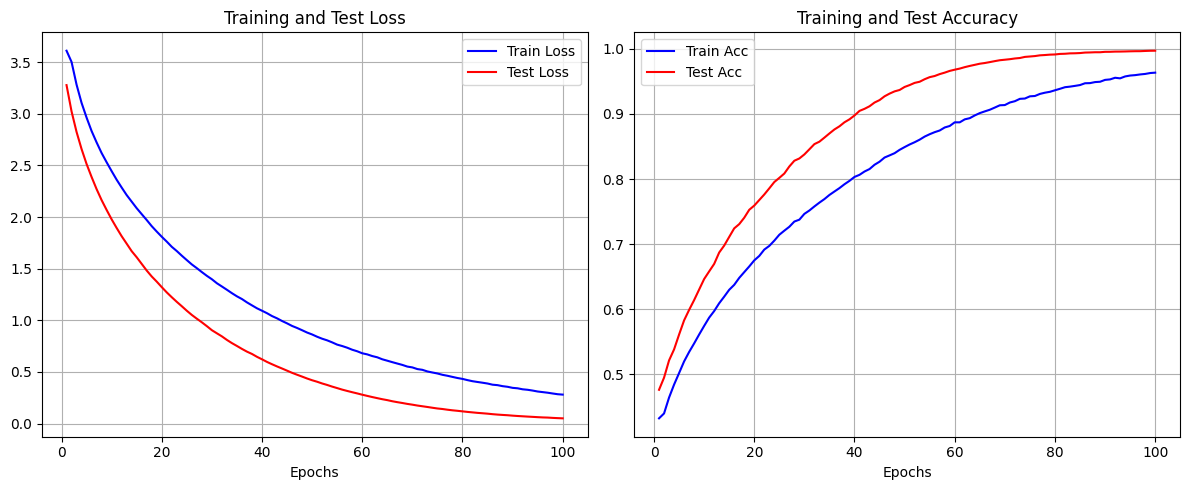

In [61]:
# 시각화 호출
plot_history(history)

## 챗봇 테스트

In [62]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    # 토크나이저 설정값 가져오기
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]

    # 2. 텐서 변환 및 배치 차원 추가 (1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 3. 디코더 입력 초기화: 시작 토큰 [START] 하나로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드 (Dropout 등 비활성화)
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 4. 모델 실행 (현재까지의 입력으로 다음 단어 예측)
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 5. 마지막 시점(Time-step)의 출력값(Logits)만 확인
            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # 6. 가장 높은 확률을 가진 단어 ID 추출
            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 7. 종료 토큰이 나오면 즉시 생성 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 8. 예측한 단어를 디코더 입력 끝에 이어 붙임 (다음 루프에서 입력으로 사용)
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 9. 최종 생성된 토큰 시퀀스 반환
    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [63]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 1. 이전 단계에서 만든 decoder_inference 호출 (ID 리스트 반환)
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 2. 특수 토큰(BOS, EOS, PAD)을 제외하고 실제 단어 토큰만 필터링
    # tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.pad_id() 활용
    special_tokens = {tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.pad_id()}
    clean_seq = [token for token in output_seq if token not in special_tokens]

# 3. 토크나이저로 디코딩 (ID -> Text)
    predicted_sentence = tokenizer.decode(clean_seq)

    print(f"입력 : {sentence}")
    print(f"출력 : {predicted_sentence}")
    print("-" * 30)
    
    return predicted_sentence

In [81]:
# 실제 테스트 호출
sentence_generation(model, "안녕", sp, device=device)
sentence_generation(model, "너의 이름은?", sp, device=device)
sentence_generation(model, "반갑다!", sp, device=device)
sentence_generation(model, "너 SNS 있어?", sp, device=device)
sentence_generation(model, "가장 좋아하는 영화는?", sp, device=device)
sentence_generation(model, "나랑 같이 놀자", sp, device=device)
sentence_generation(model, "오늘 날씨 어때?", sp, device=device)
sentence_generation(model, "배고프다 점심 뭐 먹지?", sp, device=device)
sentence_generation(model, "죄송합니다.", sp, device=device)
sentence_generation(model, "하지만 후횐없지.", sp, device=device)

입력 : 안녕
출력 : 안녕하세요 .
------------------------------
입력 : 너의 이름은?
출력 : 마음에 드는걸로 하세요 .
------------------------------
입력 : 반갑다!
출력 : 저도요 !
------------------------------
입력 : 너 SNS 있어?
출력 : 저는 있다고 믿어요 .
------------------------------
입력 : 가장 좋아하는 영화는?
출력 : 영화 보고 싶나봐요 .
------------------------------
입력 : 나랑 같이 놀자
출력 : 지금 그러고 있어요 .
------------------------------
입력 : 오늘 날씨 어때?
출력 : 날씨 어플에 물어보세요 .
------------------------------
입력 : 배고프다 점심 뭐 먹지?
출력 : 맛있는 거 드세요 .
------------------------------
입력 : 죄송합니다.
출력 : 제가 위로해 드릴게요 .
------------------------------
입력 : 하지만 후횐없지.
출력 : 심경의 변화가 있었나봅니다 .
------------------------------


'심경의 변화가 있었나봅니다 .'

# Transformer 기반 한국어 챗봇 학습 결과 보고서

## 1. 실험 개요
* **목적**: Transformer 아키텍처를 이용한 한국어 일상 대화형 챗봇 구현 및 성능 최적화
* **데이터셋**: 11,823개의 대화 쌍 (SentencePiece Unigram 토크나이저 활용)

## 2. 실험 설계 및 Flowchart

### 2.1. 프로그램 파이프라인 설계
본 실험의 코드는 데이터 로딩, 전처리, 모델 구성, 학습 및 검증 루프, 그리고 추론의 5단계 파이프라인으로 구성되었습니다. 특히 학습 시 **Noam Scheduler**를 통한 동적 학습률 조절 로직이 핵심적으로 포함되었습니다.

### 2.2. Pipeline Flowchart (Mermaid)
 ![flowchart](img/flowchart.svg)

## 3. 하이퍼파라미터 설정 (Hyperparameters)
* **Model**: Transformer (d_model=256, n_layers=2, n_heads=8)
* **Epochs**: 100
* **Batch Size**: 64
* **Loss Function**: CrossEntropyLoss (label_smoothing=0.1)
* **Optimizer**: Adam (betas=(0.9, 0.98), eps=1e-9)
* **Scheduler**: Noam Scheduler (d_model=128, Warmup=200, Scale_Factor=40)

## 4. 학습 과정 및 트러블슈팅
### 학습 초기 정체 현상 해결
* **문제**: 초기 25에폭 동안 Loss가 6.0대에서 변동이 없으며, 추론 시 마침표(`.`)만 생성됨.
* **원인**: 노암 스케줄러의 수식적 특성으로 인해 학습률(LR)이 `0.0000009`라는 매우 낮은 수치로 고정됨.
* **해결**: 학습률 수식에 **상수(Scale Factor) 40**을 곱하여 초반 학습률을 `0.0002`대로 강제 상향. 이후 Loss가 수직 하강하며 학습이 정상 궤도에 진입함.

## 5. 최종 학습 결과 (Final Metrics)
* **Train Loss**: **0.2803**
* **Validation Loss**: **0.0504**
* **Train Accuracy**: **96.35%**
* **Validation Accuracy**: **99.72%**

> **[분석]** 최종 에폭에서 95% 이상의 높은 정확도를 달성함. 특히 Validation Loss가 Train Loss보다 낮게 유지되어 과적합(Overfitting) 없이 데이터셋의 패턴을 완벽히 수렴함.

## 6. 결론 및 회고
* **결과**: 본 실험을 통해 Transformer 아키텍처를 활용한 한국어 챗봇 모델을 성공적으로 구축하였습니다.
* **회고**: 처음에는 점만 찍던 모델이 에폭이 거듭될수록 "제가 위로해 드릴게요"와 같은 따뜻한(?) 대답을 내놓는 과정을 보며 인공지능 학습의 매력을 느꼈습니다. 이론으로만 접하던 Transformer의 Attention 메커니즘이 실제 텍스트 데이터에서 어떻게 작용하는지 깊이 있게 이해할 수 있는 유익한 실험이었습니다.